In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.binning import add_seg_info, mean_bins
from cns.analyze.genome import fig_genome_groups
from cns.utils.selection import get_cns_for_type
from cns.data_utils import load_merged_samples, load_merged_bins, select_CNS_samples

In [50]:
samples_df = load_merged_samples()
cns_df = load_merged_bins(samples_df, "3MB")

<Axes: xlabel='type'>

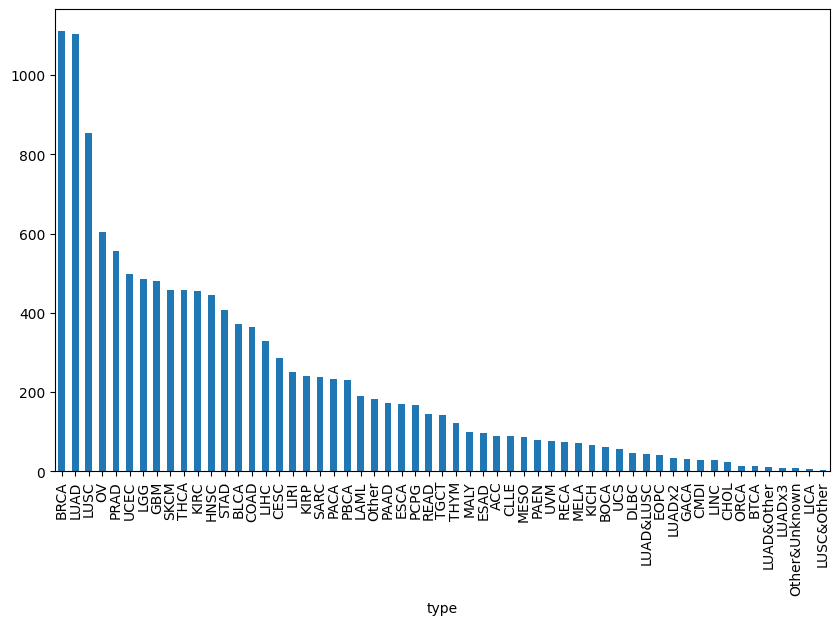

In [51]:
plt.rcParams["figure.figsize"] = (10,6)
samples_df["type"].value_counts().plot(kind="bar")

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

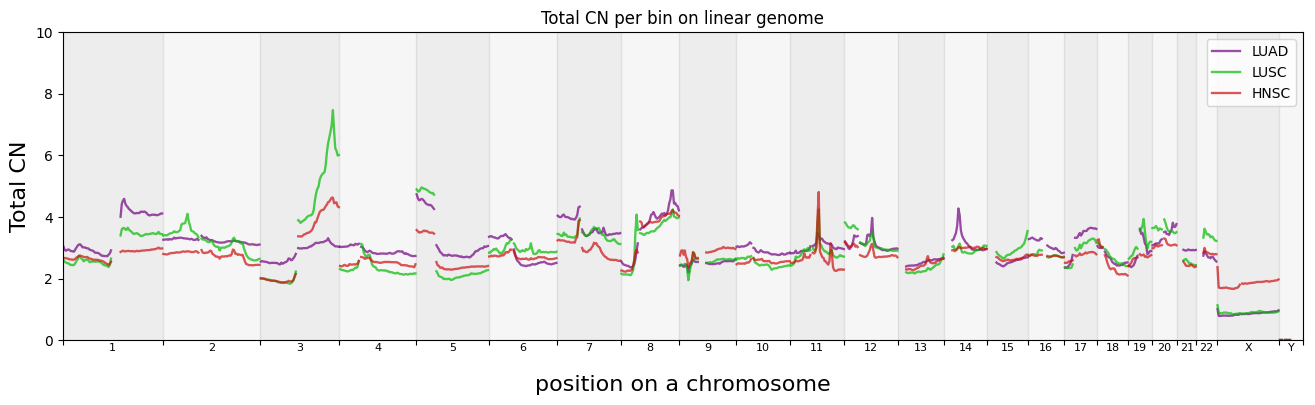

In [53]:
types = ["LUAD", "LUSC", "HNSC"]
selection = [mean_bins(get_cns_for_type(cns_df, samples_df, type)) for type in types]
fig_genome_groups(selection, types)

In [54]:
tcga_set = samples_df.query("source == 'TCGA'")
tcga_cns = select_CNS_samples(cns_df, tcga_set)
top_6 = tcga_set.value_counts("type")[:6].index.values

In [55]:
selection_tcga = [mean_bins(get_cns_for_type(cns_df, samples_df, type)) for type in top_6]

(<Figure size 3200x800 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

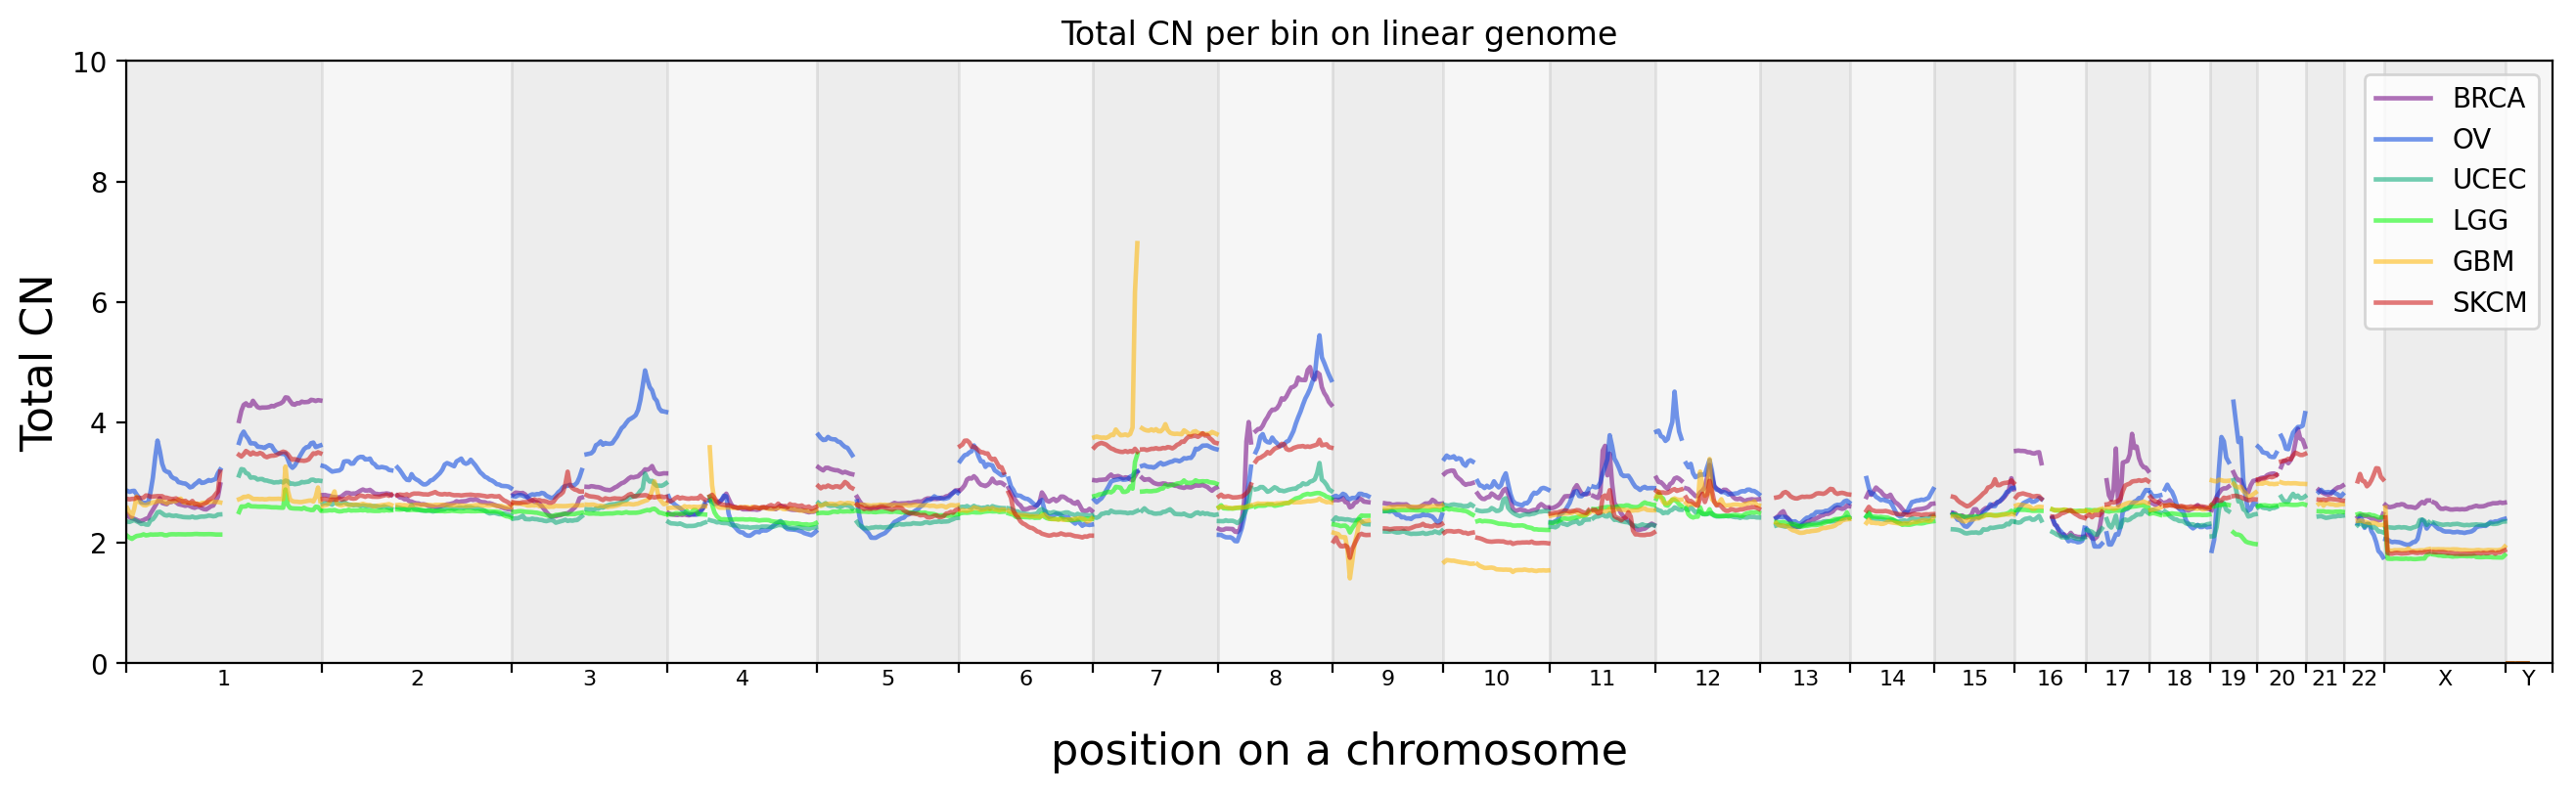

In [56]:
fig_genome_groups(selection_tcga, top_6, dpi=200)

In [72]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True) if len(x) > 50 else x, include_groups=False).reset_index().set_index('sample_id')
# select only 50 samples for each type


In [73]:
sub_samples

,type,sex,chrom_count,chrom_missing,cover_bases_aut,cover_bases_sex,cover_bases_tot,cover_frac_aut,cover_frac_sex,cover_frac_tot,...,ane_major_cn_frac_aut,ane_minor_cn_frac_aut,ane_total_cn_frac_aut,ane_major_cn_sex,ane_minor_cn_sex,ane_total_cn_sex,ane_major_cn_frac_sex,ane_minor_cn_frac_sex,ane_total_cn_frac_sex,source
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5JD,ACC,xx,23.0,[],2793460709,155065370,2948526079,0.969604,0.998679,0.971091,...,0.959661,0.960025,0.548743,155270560,155270560,155270560,1.000000,1.000000,1.000000,TCGA
TCGA-OR-A5JT,ACC,xx,23.0,[],2775008689,155064723,2930073412,0.963199,0.998674,0.965013,...,0.941228,0.943168,0.394587,155270560,151955535,155270560,1.000000,0.978650,1.000000,TCGA
TCGA-OR-A5J5,ACC,xy,23.0,['chrY'],2793394978,155022280,2948417258,0.969581,0.722229,0.952430,...,0.999340,0.846872,0.464028,214644126,3022907,214644126,1.000000,0.014083,1.000000,TCGA
TCGA-OR-A5JU,ACC,xx,23.0,[],2793474397,155065370,2948539767,0.969609,0.998679,0.971095,...,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,TCGA
TCGA-OR-A5K4,ACC,xx,23.0,[],2793439623,155065370,2948504993,0.969596,0.998679,0.971084,...,0.990740,0.992943,0.289350,155270560,155270560,155270560,1.000000,1.000000,1.000000,TCGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VD-A8KN,UVM,xx,23.0,[],2793447460,155065370,2948512830,0.969599,0.998679,0.971086,...,0.034626,0.069077,0.103592,0,155270560,155270560,0.000000,1.000000,1.000000,TCGA
TCGA-V4-A9EF,UVM,xy,23.0,['chrY'],2793462710,155064828,2948527538,0.969604,0.722428,0.952466,...,0.035609,0.068733,0.104342,59373566,3015256,62388822,0.276614,0.014048,0.290662,TCGA
TCGA-YZ-A985,UVM,xx,23.0,[],2782274041,155052284,2937326325,0.965721,0.998594,0.967402,...,0.001454,0.074031,0.073069,12097660,12097660,0,0.077913,0.077913,0.000000,TCGA


In [75]:
selection = [mean_bins(select_CNS_samples(cns_df, samples)) for samples in [all_samples, sub_samples]]
fig_genome_groups(selection, ["All", "Subsample"], dpi=200)